<a href="https://colab.research.google.com/github/LBT-975/BTL_TTNT_Nhom7/blob/main/TTNT_NhOM7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# TIỀN XỬ LÝ DỮ LIỆU PHÂN TÍCH CẢM XÚC TIẾNG VIỆT
# ============================================================================
# Bài toán: Phân tích cảm xúc bình luận đánh giá sản phẩm
# Phương pháp: TF-IDF + SVM
# Chạy trên: Kaggle Notebook
#
# Pipeline gồm 8 giai đoạn:
#   1. Chuẩn hóa Unicode & chữ thường
#   2. Số hóa ngữ nghĩa Emoji → từ văn bản
#   3. Loại bỏ URL, HTML, ký tự đặc biệt thừa
#   4. Rút gọn ký tự kéo dài (elongated words)
#   5. Sửa lỗi chính tả phổ biến
#   6. Sửa lỗi viết dính chữ
#   7. Ánh xạ Teencode & từ viết tắt TMĐT (token-level matching)
#   8. Tách từ tiếng Việt (Underthesea word_tokenize)
# ============================================================================

import pandas as pd
import re
import unicodedata
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
DATA_PATH = '/content/data.csv'
OUTPUT_PATH = 'cleaned_data.csv'

USE_STOPWORDS = False


# ============================================================================
# 1. TỪ ĐIỂN EMOJI → VĂN BẢN (Emoji Semantics Translation)
# ----------------------------------------------------------------------------
# Thay vì xóa bỏ emoji (mất tín hiệu cảm xúc), ta chuyển chúng thành
# từ văn bản tương đương TRƯỚC khi xóa ký tự đặc biệt.
# ============================================================================
EMOJI_MAP = {
    # --- Tích cực cao (Positive) ---
    '❤️': ' tốt ', '❤': ' tốt ', '💖': ' tốt ', '💕': ' tốt ',
    '💗': ' tốt ', '💓': ' tốt ', '💘': ' tốt ', '💝': ' tốt ',
    '💞': ' tốt ', '🥰': ' tốt ', '😍': ' tốt ', '😘': ' tốt ',
    '😻': ' tốt ', '💋': ' tốt ', '🫶': ' tốt ',

    # --- Tích cực / Hài lòng ---
    '👍': ' tốt ', '👍🏻': ' tốt ', '👍🏼': ' tốt ',
    '👍🏽': ' tốt ', '👍🏾': ' tốt ', '👍🏿': ' tốt ',
    '👏': ' tốt ', '👏🏻': ' tốt ', '🙌': ' tốt ',
    '✅': ' tốt ', '✔️': ' tốt ', '☑️': ' tốt ',
    '💯': ' tốt ', '🎉': ' tốt ', '🎊': ' tốt ',
    '🤝': ' tốt ', '💪': ' tốt ',

    # --- Hào hứng / Khuyên dùng ---
    '🤩': ' tốt ', '🔥': ' tốt ', '⚡': ' tốt ',
    '🏆': ' tốt ', '🥇': ' tốt ', '🎯': ' tốt ',

    # --- Vui vẻ ---
    '😊': ' vui ', '🙂': ' vui ', '😄': ' vui ', '😃': ' vui ',
    '😁': ' vui ', '😆': ' vui ', '🤗': ' vui ', '😜': ' vui ',
    '🤪': ' vui ', '😝': ' vui ', '😋': ' vui ', '😎': ' vui ',
    '😏': ' vui ', '🙈': ' vui ', '🤭': ' vui ', '😌': ' vui ',
    '😉': ' vui ', '🫣': ' vui ',

    # --- Tiêu cực / Thất vọng ---
    '😭': ' xấu ', '😢': ' buồn ', '😥': ' buồn ', '😿': ' buồn ',
    '🥺': ' buồn ', '😞': ' buồn ', '😔': ' buồn ', '😩': ' buồn ',
    '😫': ' buồn ', '😪': ' buồn ', '😰': ' buồn ',
    '😓': ' buồn ', '😟': ' buồn ', '🙁': ' buồn ', '☹️': ' buồn ',

    # --- Tiêu cực cao / Phẫn nộ ---
    '😡': ' xấu ', '🤬': ' xấu ', '😠': ' xấu ',
    '👎': ' xấu ', '👎🏻': ' xấu ', '👎🏼': ' xấu ',
    '💔': ' xấu ', '🖕': ' xấu ',

    # --- Bài xích / Chất lượng tệ ---
    '🤮': ' xấu ', '👿': ' xấu ', '😤': ' xấu ',
    '💩': ' xấu ', '🗑️': ' xấu ',

    # --- Ngạc nhiên / Trung tính ---
    '😱': ' ngạc_nhiên ', '😲': ' ngạc_nhiên ',
    '🤔': ' suy_nghĩ ', '🧐': ' suy_nghĩ ',
    '😐': ' bình_thường ', '😑': ' bình_thường ', '😶': ' bình_thường ',

    # --- Định lượng chất lượng ---
    '⭐': ' năm_sao ', '🌟': ' năm_sao ', '💫': ' năm_sao ',

    # --- Âm nhạc / Biểu cảm phụ ---
    '🎶': ' vui ', '🎵': ' vui ', '🎼': ' vui ',

    # --- Biểu tượng dạng text (emoticon) ---
    '<3': ' tốt ', ':3': ' vui ', ':)': ' vui ', ':))': ' vui ',
    ':)))': ' vui ', ':(': ' buồn ', ':((': ' buồn ',
    ':(((': ' buồn ', ':D': ' vui ', 'XD': ' vui ',
    '^_^': ' vui ', '^^': ' vui ', '>_<': ' buồn ',
    '*_*': ' tốt ', 'T_T': ' buồn ', '-_-': ' bình_thường ',
    ':P': ' vui ', ':p': ' vui ', ';)': ' vui ',
    'o_O': ' ngạc_nhiên ', 'O_o': ' ngạc_nhiên ',
}


# ============================================================================
# 2. TỪ ĐIỂN TEENCODE & VIẾT TẮT THƯƠNG MẠI ĐIỆN TỬ (MỞ RỘNG)
# ----------------------------------------------------------------------------
# Hơn 150 mapping, bao phủ các viết tắt phổ biến nhất của người tiêu dùng
# Việt Nam trên các sàn TMĐT (Shopee, Tiki, Lazada).
# Sử dụng token-level matching (so khớp toàn vẹn từ) để tránh thay thế sai.
# ============================================================================
TEENCODE_MAP = {
    # ===== Từ phủ định =====
    'k': 'không', 'ko': 'không', 'khg': 'không', 'kh': 'không',
    'khong': 'không', 'kg': 'không', 'hk': 'không', 'hkg': 'không',
    'kp': 'không phải', 'kfai': 'không phải', 'kphai': 'không phải',
    'hem': 'không', 'hông': 'không', 'hong': 'không',
    'éo': 'không', 'đéo': 'không',
    'chx': 'chưa',
    'cx': 'cũng', 'cg': 'cũng', 'cug': 'cũng', 'cũg': 'cũng',
    'chg': 'chẳng',

    # ===== Đại từ =====
    'mng': 'mọi người', 'mn': 'mọi người', 'm.n': 'mọi người',
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình', 'mih': 'mình',
    'minh': 'mình', 'mìk': 'mình', 'minhk': 'mình',
    'nv': 'nhân viên',
    'bn': 'bạn',
    'tui': 'tôi',
    'ny': 'người yêu', 'ck': 'chồng', 'vk': 'vợ',
    'ng': 'người',

    # ===== Đại từ nghi vấn =====
    'j': 'gì', 'gi': 'gì', 'gj': 'gì',
    'z': 'vậy', 'dz': 'vậy', 'v': 'vậy', 'vay': 'vậy',

    # ===== Trạng từ / Động từ tình thái =====
    'dc': 'được', 'dk': 'được', 'đc': 'được', 'đk': 'được',
    'duoc': 'được', 'đuợc': 'được', 'đươc': 'được',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'roi': 'rồi',
    'lun': 'luôn', 'luon': 'luôn',
    'lm': 'làm', 'lam': 'làm',
    'bt': 'bình thường', 'bthg': 'bình thường', 'bth': 'bình thường',
    'bthường': 'bình thường',
    'vs': 'với', 'voi': 'với',
    'ntn': 'như thế này', 'nvay': 'như vậy',
    'w': 'quá', 'wa': 'quá', 'qá': 'quá', 'wá': 'quá',
    'nhiu': 'nhiều', 'nhìu': 'nhiều', 'nhều': 'nhiều',
    'nhahh': 'nhanh',

    # ===== Từ biểu cảm lịch sự =====
    'tks': 'cảm ơn', 'tk': 'cảm ơn', 'thanks': 'cảm ơn',
    'thank': 'cảm ơn', 'thankss': 'cảm ơn', 'thenks': 'cảm ơn',
    'thks': 'cảm ơn',
    'sr': 'xin lỗi', 'sorry': 'xin lỗi', 'sory': 'xin lỗi',

    # ===== Tính từ đánh giá =====
    'ok': 'tốt', 'oke': 'tốt', 'okie': 'tốt', 'okz': 'tốt',
    'okela': 'tốt', 'oki': 'tốt', 'okay': 'tốt',
    'gud': 'tốt', 'good': 'tốt', 'gooddd': 'tốt',
    'gd': 'tốt', 'goood': 'tốt',
    'nice': 'tốt', 'niceee': 'tốt',
    'perfect': 'hoàn hảo', 'great': 'tuyệt vời',
    'super': 'siêu', 'excellent': 'xuất sắc',
    'recommend': 'khuyên dùng', 'bad': 'xấu',
    'xau': 'xấu', 'tot': 'tốt', 'dep': 'đẹp',
    'đep': 'đẹp', 'depp': 'đẹp', 'dẹp': 'đẹp',
    'thik': 'thích', 'thix': 'thích',
    'ưg': 'ưng', 'ug': 'ưng',
    'siu': 'siêu', 'ciu': 'buồn',
    'hịn': 'đẹp', 'ghiền': 'thích',

    # ===== Biểu cảm cười / khóc =====
    'hi': 'vui', 'hii': 'vui', 'hiii': 'vui',
    'hihi': 'vui', 'hehe': 'vui',
    'huhu': 'buồn', 'huhuu': 'buồn', 'huhuhu': 'buồn',
    'hic': 'buồn', 'hicc': 'buồn',

    # ===== Danh từ thương mại =====
    'shop': 'cửa hàng', 'sp': 'sản phẩm',
    'spm': 'sản phẩm', 'sanpham': 'sản phẩm',
    'ship': 'giao hàng', 'shipper': 'người giao hàng',
    'shiper': 'người giao hàng', 'shoppe': 'shopee',
    'dt': 'điện thoại',
    'sale': 'giảm giá',
    'sz': 'size', 'soze': 'size',
    'ncc': 'nhà cung cấp',
    'hsd': 'hạn sử dụng', 'nsx': 'ngày sản xuất',
    'vc': 'vận chuyển', 'ghtk': 'giao hàng tiết kiệm',

    # ===== Danh từ logistics (viết sai dấu phổ biến) =====
    'hàg': 'hàng', 'hag': 'hàng', 'hang': 'hàng',

    # ===== Động từ tương tác =====
    'rep': 'trả lời', 'ib': 'nhắn tin',
    'inbox': 'nhắn tin', 'nt': 'nhắn tin',
    'onl': 'trực tuyến', 'online': 'trực tuyến',
    'fb': 'phản hồi', 'nch': 'nói chuyện',

    # ===== Cụm từ viết tắt phổ biến =====
    'ncl': 'nói chung là', 'nchung': 'nói chung',
    'trc': 'trước', 'truoc': 'trước',
    'nua': 'nữa', 'nưa': 'nữa',
    'lg': 'lượng', 'cl': 'chất lượng',
    'potay': 'bó tay',

    # ===== Tiếng Anh phổ biến trong review =====
    'value': 'giá trị', 'money': 'tiền',
    'quality': 'chất lượng', 'price': 'giá',
    'delivery': 'giao hàng', 'fast': 'nhanh',
    'slow': 'chậm', 'beautiful': 'đẹp',
    'ugly': 'xấu', 'cheap': 'rẻ', 'expensive': 'đắt',
    'love': 'yêu', 'hate': 'ghét', 'like': 'thích',
    'fake': 'giả', 'real': 'thật',

    # ===== Phiên âm / viết sai phổ biến =====
    'form': 'dáng', 'foem': 'dáng', 'from': 'dáng', 'phom': 'dáng',
    'fai': 'phải', 'fải': 'phải',
    'dã man': 'cực kỳ',
    'vãi': 'rất', 'vại': 'rất',
    'khỏi chê': 'rất tốt', 'hết sảy': 'rất tốt',
    'chán đời': 'rất xấu',

    # ===== Số + sao (rating) =====
    '5sao': 'năm sao', '5*': 'năm sao', '4*': 'bốn sao',
    '3*': 'ba sao', '2*': 'hai sao', '1*': 'một sao',
    '10đ': 'mười điểm', '5s': 'năm sao',
}


# ============================================================================
# 3. TỪ ĐIỂN SỬA LỖI CHÍNH TẢ PHỔ BIẾN
# ----------------------------------------------------------------------------
# Bao gồm các lỗi viết sai phụ âm đầu, sai nguyên âm, thiếu dấu, v.v.
# Sắp xếp theo độ dài giảm dần khi xử lý để tránh thay thế nhầm.
# ============================================================================
SPELLING_CORRECTIONS = {
    # --- Lỗi "sản phẩm" (rất phổ biến) ---
    'sản phr': 'sản phẩm', 'sản fẩm': 'sản phẩm', 'sảm phẩm': 'sản phẩm',
    'sản phầm': 'sản phẩm', 'sản phẩn': 'sản phẩm', 'sản phản': 'sản phẩm',
    'san phạm': 'sản phẩm', 'sản phẩ': 'sản phẩm',

    # --- Lỗi "chất lượng" ---
    'chất lượg': 'chất lượng', 'chất luợng': 'chất lượng',
    'chất luong': 'chất lượng', 'chất lương': 'chất lượng',
    'chat luong': 'chất lượng',

    # --- Lỗi "giao hàng" ---
    'giao hàg': 'giao hàng', 'giao hang': 'giao hàng',
    'giao hành': 'giao hàng',

    # --- Lỗi "tuyệt vời" ---
    'tuyệt vờ': 'tuyệt vời', 'tuyệt vờii': 'tuyệt vời',
    'tuyet voi': 'tuyệt vời', 'tuyệt vờiO': 'tuyệt vời',

    # --- Lỗi "đóng gói" ---
    'đóng goi': 'đóng gói', 'dong goi': 'đóng gói', 'đóng gỏi': 'đóng gói',

    # --- Lỗi "chắc chắn" ---
    'chăc chăn': 'chắc chắn', 'chắc chắc': 'chắc chắn', 'chac chan': 'chắc chắn',

    # --- Lỗi "nhiệt tình" ---
    'nhiet tinh': 'nhiệt tình', 'nhiệt tinhg': 'nhiệt tình',

    # --- Lỗi "hài lòng" ---
    'hài lòg': 'hài lòng', 'hai long': 'hài lòng',

    # --- Lỗi "phục vụ" ---
    'phục vu': 'phục vụ', 'phụ vụ': 'phục vụ', 'phuc vu': 'phục vụ',

    # --- Lỗi "thất vọng" ---
    'thất vọg': 'thất vọng', 'that vong': 'thất vọng',

    # --- Lỗi "uy tín" ---
    'uy tin': 'uy tín',

    # --- Lỗi "giống hình" ---
    'giống hjnh': 'giống hình', 'giống hinh': 'giống hình',
    'giong hinh': 'giống hình',

    # --- Lỗi "sử dụng" ---
    'sử dụg': 'sử dụng', 'su dung': 'sử dụng', 'sủ dụng': 'sử dụng',

    # --- Lỗi "đáng tiền" ---
    'đág tiền': 'đáng tiền', 'dang tien': 'đáng tiền',

    # --- Lỗi "cảm ơn" ---
    'cam on': 'cảm ơn', 'cám ơn': 'cảm ơn',

    # --- Lỗi "dày dặn" ---
    'day dan': 'dày dặn', 'dày dăn': 'dày dặn',

    # --- Lỗi "vận chuyển" ---
    'vận chuyên': 'vận chuyển', 'van chuyen': 'vận chuyển',

    # --- Lỗi "co giãn" ---
    'co gian': 'co giãn', 'co giản': 'co giãn',

    # --- Lỗi "kích thước" ---
    'kich thuoc': 'kích thước', 'kich thươc': 'kích thước',

    # --- Lỗi "mềm mịn" ---
    'mem min': 'mềm mịn',

    # --- Lỗi "tương xứng" ---
    'tương sứng': 'tương xứng',

    # --- Lỗi khác ---
    'dỗm': 'kém chất lượng', 'dom': 'kém chất lượng',
    'hãm': 'tệ', 'hớ': 'bị lừa',
    'sácg': 'sách', 'mảu': 'màu',
    'chât vải': 'chất vải', 'chat vai': 'chất vải',
    'thời gjàn': 'thời gian', 'thoi gian': 'thời gian',
    'chup': 'chụp',
}


# ============================================================================
# 4. TỪ ĐIỂN VIẾT DÍNH CHỮ PHỔ BIẾN
# ----------------------------------------------------------------------------
# Người dùng TMĐT thường gõ nhanh, không dấu cách giữa các từ.
# ============================================================================
CONCAT_PATTERNS = [
    # --- Cụm đánh giá sản phẩm ---
    (r'giaohàng', 'giao hàng'), (r'giaohang', 'giao hàng'),
    (r'sảnphẩm', 'sản phẩm'), (r'sanpham', 'sản phẩm'),
    (r'chấtlượng', 'chất lượng'), (r'chatluong', 'chất lượng'),
    (r'đónggói', 'đóng gói'), (r'donggoi', 'đóng gói'),
    (r'tuyệtvời', 'tuyệt vời'), (r'tuyetvoi', 'tuyệt vời'),
    (r'hàilòng', 'hài lòng'), (r'hailong', 'hài lòng'),
    (r'cửahàng', 'cửa hàng'), (r'cuahang', 'cửa hàng'),
    (r'giátiền', 'giá tiền'), (r'giatien', 'giá tiền'),
    (r'phùhợp', 'phù hợp'), (r'phuhop', 'phù hợp'),

    # --- Cụm tính từ ---
    (r'rấtđẹp', 'rất đẹp'), (r'ratdep', 'rất đẹp'),
    (r'rấttốt', 'rất tốt'), (r'rattot', 'rất tốt'),
    (r'khôngtốt', 'không tốt'), (r'khongtot', 'không tốt'),
    (r'đẹplắm', 'đẹp lắm'), (r'deplam', 'đẹp lắm'),
    (r'xấulắm', 'xấu lắm'),

    # --- Cụm thời gian / dịch vụ ---
    (r'thờigian', 'thời gian'), (r'thoigian', 'thời gian'),
    (r'đángtiền', 'đáng tiền'), (r'dangtien', 'đáng tiền'),
    (r'ủnghộ', 'ủng hộ'), (r'ungho', 'ủng hộ'),
    (r'nhiệttình', 'nhiệt tình'), (r'nhiệttinh', 'nhiệt tình'),
    (r'cẩnthận', 'cẩn thận'), (r'canthan', 'cẩn thận'),
    (r'chắcchắn', 'chắc chắn'), (r'chacchan', 'chắc chắn'),
    (r'thoảimái', 'thoải mái'), (r'thoaimai', 'thoải mái'),

    # --- Cụm cảm xúc ---
    (r'thấtvọng', 'thất vọng'), (r'thatvong', 'thất vọng'),
    (r'vuivẻ', 'vui vẻ'),
    (r'buồncười', 'buồn cười'),
    (r'mấttiền', 'mất tiền'),
    (r'khỏichê', 'không chê được'),
]


# ============================================================================
# 5. STOPWORDS TIẾNG VIỆT (từ chức năng, không mang cảm xúc)
# ----------------------------------------------------------------------------
# CHÚ Ý: Mặc định USE_STOPWORDS = False. Trong bài toán Sentiment Analysis,
# nhiều từ "rất", "quá", "lắm" thực sự mang ngữ nghĩa quan trọng.
# Chỉ bật nếu bạn chắc chắn muốn loại bỏ.
# ============================================================================
VIETNAMESE_STOPWORDS = {
    'và', 'của', 'có', 'là', 'cho', 'được', 'đã', 'hay',
    'các', 'này', 'với', 'thì', 'đó', 'để', 'khi',
    'từ', 'theo', 'một', 'những', 'do', 'bởi',
    'nên', 'vì', 'tại', 'bị', 'về', 'trong', 'trên',
    'dưới', 'ra', 'vào', 'lên', 'xuống', 'đi', 'đến',
    'nơi', 'đây', 'kia', 'ấy', 'nọ',
    'cùng', 'cứ', 'thế', 'vẫn', 'ngay',
    'ạ', 'à', 'ơi', 'nhé', 'nha', 'nhá', 'nè', 'thôi',
}


# ============================================================================
#                    CÁC HÀM XỬ LÝ TỪNG GIAI ĐOẠN
# ============================================================================

def replace_emojis(text):
    """
    GIAI ĐOẠN 1: Thay thế emoji/emoticon bằng từ văn bản tương đương.
    Phải thực hiện TRƯỚC khi xóa ký tự đặc biệt để bảo toàn tín hiệu cảm xúc.
    Ví dụ: "hàng đẹp 👍❤️" → "hàng đẹp tốt tốt"
    """
    # Thay thế text emoticons dài trước (để tránh conflict)
    # Ví dụ: ":))" phải match trước ":)", "<3" trước "<"
    text_emoticons_sorted = sorted(
        [(k, v) for k, v in EMOJI_MAP.items()
         if all(c in ':<>()_^*3DPpXxTtOo;/-' or c.isalpha() for c in k)],
        key=lambda x: len(x[0]), reverse=True
    )
    for emoticon, replacement in text_emoticons_sorted:
        text = text.replace(emoticon, replacement)

    # Thay thế Unicode emoji (👍, ❤️, 😍, v.v.)
    for emoji_char, replacement in EMOJI_MAP.items():
        if emoji_char in text:
            text = text.replace(emoji_char, replacement)

    return text


def normalize_unicode(text):
    """
    GIAI ĐOẠN 2: Chuẩn hóa Unicode NFC và chuyển chữ thường.
    Đảm bảo "Đẹp", "ĐẸP", "đẹp" → cùng 1 tọa độ vector.
    """
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    return text


def remove_noise(text):
    """
    GIAI ĐOẠN 3: Loại bỏ URL, HTML tags, email, hashtag, ký tự đặc biệt.
    Giữ lại chữ cái tiếng Việt, số và khoảng trắng.
    """
    # Xóa URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Xóa HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Xóa email
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    # Xóa hashtags và mentions
    text = re.sub(r'[#@]\w+', ' ', text)
    # Xóa ký hiệu tiền tệ kèm số (175000₫, 110.000 đ)
    text = re.sub(r'\d+[₫đ]', ' ', text)
    text = re.sub(r'\d+[\.,]\d+', ' ', text)
    # Xóa TẤT CẢ ký tự đặc biệt, giữ lại chữ tiếng Việt + số + khoảng trắng + gạch dưới
    text = re.sub(
        r'[^\sa-zA-Z0-9_'
        r'àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩ'
        r'òóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ'
        r'ÀÁẠẢÃÂẦẤẬẨẪĂẰẮẶẲẴÈÉẸẺẼÊỀẾỆỂỄÌÍỊỈĨ'
        r'ÒÓỌỎÕÔỒỐỘỔỖƠỜỚỢỞỠÙÚỤỦŨƯỪỨỰỬỮỲÝỴỶỸĐ]',
        ' ', text
    )
    # Xóa các số đứng riêng lẻ (không ghép với từ)
    text = re.sub(r'\b\d+\b', ' ', text)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def reduce_elongation(text):
    """
    GIAI ĐOẠN 4: Rút gọn ký tự kéo dài (elongated words).
    Người dùng hay kéo dài chữ để nhấn mạnh cảm xúc:
      "đẹpppp" → "đẹp"
      "rẻeee"  → "rẻ"
      "nhanhhh" → "nhanh"
    Tiếng Việt rất hiếm khi có ký tự lặp đôi hợp lệ,
    nên nén tất cả ký tự lặp >= 2 về 1.
    """
    # Nén phụ âm lặp >= 3 lần về 1
    text = re.sub(r'([a-zàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ])\1{2,}', r'\1', text)
    # Nén nguyên âm lặp >= 2 lần về 1
    text = re.sub(r'([aeiouyàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹ])\1{1,}', r'\1', text)
    return text


def fix_common_spelling(text):
    """
    GIAI ĐOẠN 5: Sửa lỗi chính tả phổ biến bằng từ điển.
    Sắp xếp theo độ dài giảm dần (cụm dài match trước) để tránh thay thế nhầm.
    Ví dụ: "sản phr rất tốt" → "sản phẩm rất tốt"
    """
    sorted_corrections = sorted(SPELLING_CORRECTIONS.items(), key=lambda x: len(x[0]), reverse=True)
    for wrong, correct in sorted_corrections:
        # Sử dụng word boundary (\b) để chỉ thay thế khi match toàn bộ từ/cụm
        pattern = r'\b' + re.escape(wrong) + r'\b'
        text = re.sub(pattern, correct, text)
    return text


def fix_concatenated_words(text):
    """
    GIAI ĐOẠN 6a: Sửa lỗi viết dính chữ phổ biến.
    Ví dụ: "giaohàng" → "giao hàng", "sảnphẩm" → "sản phẩm"
    """
    for pattern, replacement in CONCAT_PATTERNS:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text


def map_teencode(text):
    """
    GIAI ĐOẠN 6b: Ánh xạ teencode & từ viết tắt TMĐT.
    Sử dụng greedy matching: thử ghép 3 từ → 2 từ → 1 từ.
    So khớp toàn vẹn từ (token-level) để tránh thay thế sai
    các cụm ký tự con nằm bên trong một từ hợp lệ khác.
    Ví dụ: "sp ko dc" → "sản phẩm không được"
    """
    words = text.split()
    result = []
    i = 0
    while i < len(words):
        matched = False
        # Thử ghép 3 từ → 2 từ → 1 từ (ưu tiên cụm dài hơn)
        for n in range(min(3, len(words) - i), 0, -1):
            phrase = ' '.join(words[i:i + n])
            if phrase in TEENCODE_MAP:
                result.append(TEENCODE_MAP[phrase])
                i += n
                matched = True
                break
        if not matched:
            result.append(words[i])
            i += 1
    return ' '.join(result)


def tokenize_vietnamese(text):
    """
    GIAI ĐOẠN 7: Tách từ tiếng Việt sử dụng Underthesea.
    Nối các âm tiết của từ ghép bằng dấu gạch dưới (_).
    Ví dụ: "sản phẩm giao hàng nhanh" → "sản_phẩm giao_hàng nhanh"
    Đây là bước QUYẾT ĐỊNH vì tiếng Việt là ngôn ngữ đa âm tiết.
    """
    try:
        from underthesea import word_tokenize
        text = word_tokenize(text, format="text")
    except ImportError:
        print("⚠️ Thư viện underthesea chưa được cài. Bỏ qua bước tách từ.")
    except Exception:
        # Nếu underthesea gặp lỗi với câu quá ngắn hoặc ký tự lạ → giữ nguyên
        pass
    return text


def remove_stopwords(text, stopwords_set):
    """
    GIAI ĐOẠN 8 (Tùy chọn): Loại bỏ stopwords tiếng Việt.
    Mặc định TẮT (USE_STOPWORDS = False).
    """
    words = text.split()
    filtered = [w for w in words if w.replace('_', ' ') not in stopwords_set and w not in stopwords_set]
    return ' '.join(filtered)


def remove_short_tokens(text, min_length=2):
    """
    Loại bỏ các token quá ngắn (1 ký tự) ngoại trừ các từ 1 âm tiết có nghĩa.
    """
    meaningful_single = {'đẹp', 'xấu', 'tốt', 'rẻ', 'dở', 'ổn', 'êm', 'ẩu'}
    words = text.split()
    filtered = [w for w in words if len(w.replace('_', '')) >= min_length or w in meaningful_single]
    return ' '.join(filtered)


# ============================================================================
#              PIPELINE TỔNG HỢP - GỌI TẤT CẢ CÁC GIAI ĐOẠN
# ============================================================================

def full_preprocess(text):
    """
    Pipeline tiền xử lý hoàn chỉnh 8 giai đoạn.
    Input:  "Sp quá đẹpppp 👍❤️ shop ship nhanh lun, tks shop nhé :))"
    Output: "sản_phẩm quá đẹp tốt tốt cửa_hàng giao_hàng nhanh luôn cảm_ơn cửa_hàng vui"
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""

    # 1. Chuẩn hóa Unicode + lowercase
    text = normalize_unicode(text)

    # 2. Thay thế Emoji → văn bản (TRƯỚC khi xóa ký tự đặc biệt)
    text = replace_emojis(text)

    # 3. Loại bỏ URL, HTML, ký tự đặc biệt
    text = remove_noise(text)

    # 4. Rút gọn ký tự kéo dài ("đẹpppp" → "đẹp")
    text = reduce_elongation(text)

    # 5. Sửa lỗi chính tả phổ biến
    text = fix_common_spelling(text)

    # 6a. Sửa lỗi viết dính chữ ("giaohàng" → "giao hàng")
    text = fix_concatenated_words(text)

    # 6b. Ánh xạ teencode & từ viết tắt ("ko dc" → "không được")
    text = map_teencode(text)

    # 7. Tách từ tiếng Việt ("sản phẩm" → "sản_phẩm")
    text = tokenize_vietnamese(text)

    # 8. (Tùy chọn) Loại bỏ stopwords
    if USE_STOPWORDS:
        text = remove_stopwords(text, VIETNAMESE_STOPWORDS)

    # 9. Loại bỏ token quá ngắn (1 ký tự vô nghĩa)
    text = remove_short_tokens(text)

    # 10. Chuẩn hóa khoảng trắng cuối cùng
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ============================================================================
#                           THỰC THI CHÍNH
# ============================================================================

print("=" * 70)
print("  PIPELINE TIỀN XỬ LÝ DỮ LIỆU PHÂN TÍCH CẢM XÚC TIẾNG VIỆT")
print("  TF-IDF + SVM | Kaggle Vietnamese Sentiment Analysis")
print("=" * 70)

# ----------------------------------------------------------------------
# BƯỚC 0: Cài đặt thư viện Underthesea (tự động trên Kaggle)
# ----------------------------------------------------------------------
print("\n📦 [0/7] Kiểm tra & cài đặt thư viện underthesea...")
try:
    from underthesea import word_tokenize
    print("   ✅ underthesea đã sẵn sàng.")
except ImportError:
    print("   ⏳ Đang cài đặt underthesea (mất ~1-2 phút)...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'underthesea', '-q'])
    from underthesea import word_tokenize
    print("   ✅ Cài đặt underthesea thành công.")

# ----------------------------------------------------------------------
# BƯỚC 1: Đọc dữ liệu
# ----------------------------------------------------------------------
print(f"\n📂 [1/7] Đang đọc file: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f"   ✅ Đọc thành công: {len(df):,} dòng × {len(df.columns)} cột")
print(f"   📋 Các cột: {list(df.columns)}")

# ----------------------------------------------------------------------
# BƯỚC 2: Kiểm tra & làm sạch dữ liệu cơ bản
# ----------------------------------------------------------------------
print(f"\n🔍 [2/7] Kiểm tra chất lượng dữ liệu...")

# Đổi tên cột cho thống nhất (file gốc có cột: content, label, start)
if 'content' in df.columns:
    df.rename(columns={'content': 'comment'}, inplace=True)
if 'start' in df.columns:
    df.rename(columns={'start': 'rate'}, inplace=True)

# Kiểm tra null
null_counts = df.isnull().sum()
print(f"   📊 Giá trị null:\n{null_counts.to_string()}")

# Xóa dòng có comment null hoặc rỗng
original_len = len(df)
df = df.dropna(subset=['comment'])
df = df[df['comment'].str.strip().str.len() > 0]
dropped = original_len - len(df)
if dropped > 0:
    print(f"   ⚠️ Đã xóa {dropped} dòng rỗng/null")

# Xóa dòng trùng lặp
dup_count = df.duplicated(subset=['comment']).sum()
df = df.drop_duplicates(subset=['comment'], keep='first')
if dup_count > 0:
    print(f"   ⚠️ Đã xóa {dup_count} dòng trùng lặp")

print(f"   ✅ Còn lại: {len(df):,} dòng")

# ----------------------------------------------------------------------
# BƯỚC 3: Chuẩn hóa nhãn
# ----------------------------------------------------------------------
print(f"\n🏷️ [3/7] Chuẩn hóa nhãn cảm xúc...")
df['label'] = df['label'].str.strip().str.upper()

# Hiển thị phân phối nhãn dạng biểu đồ text
label_dist = df['label'].value_counts()
print(f"   📊 Phân phối nhãn:")
for label, count in label_dist.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"      {label:>4s}: {count:>6,} ({pct:5.1f}%) {bar}")

# Nếu bài toán chỉ cần 2 nhãn POS/NEG, uncomment dòng dưới:
# df = df[df['label'].isin(['POS', 'NEG'])]
# print(f"   ✅ Sau khi lọc POS/NEG: {len(df):,} dòng")

# ----------------------------------------------------------------------
# BƯỚC 4: Hiển thị mẫu dữ liệu GỐC
# ----------------------------------------------------------------------
print(f"\n📝 [4/7] Mẫu dữ liệu GỐC (10 dòng đầu):")
print("-" * 70)
for i, row in df.head(10).iterrows():
    comment = str(row['comment'])[:120]
    label = row['label']
    print(f"  [{label:>3s}] {comment}")
print("-" * 70)

# ----------------------------------------------------------------------
# BƯỚC 5: ÁP DỤNG PIPELINE TIỀN XỬ LÝ
# ----------------------------------------------------------------------
print(f"\n⚙️ [5/7] Đang chạy pipeline tiền xử lý trên {len(df):,} bình luận...")
print("   (Bước này có thể mất 5-15 phút tùy kích thước dữ liệu)")

start_time = time.time()

# === ÁP DỤNG HÀM PIPELINE CHO TỪNG DÒNG ===
df['cleaned_comment'] = df['comment'].apply(full_preprocess)

elapsed = time.time() - start_time
print(f"   ✅ Hoàn thành trong {elapsed:.1f} giây ({elapsed / 60:.1f} phút)")
print(f"   ⏱️ Tốc độ: {len(df) / elapsed:.0f} bình luận/giây")

# ----------------------------------------------------------------------
# BƯỚC 6: KIỂM TRA KẾT QUẢ & THỐNG KÊ
# ----------------------------------------------------------------------
print(f"\n📊 [6/7] Thống kê sau tiền xử lý:")
print("-" * 70)

# Thống kê độ dài ký tự
df['orig_len'] = df['comment'].str.len()
df['clean_len'] = df['cleaned_comment'].str.len()
print(f"  Độ dài trung bình (ký tự):")
print(f"    Trước xử lý: {df['orig_len'].mean():.0f} ± {df['orig_len'].std():.0f}")
print(f"    Sau xử lý:   {df['clean_len'].mean():.0f} ± {df['clean_len'].std():.0f}")
compression = (1 - df['clean_len'].sum() / df['orig_len'].sum()) * 100
print(f"    Tỷ lệ nén:   {compression:.1f}%")

# Thống kê số token
df['orig_tokens'] = df['comment'].str.split().str.len()
df['clean_tokens'] = df['cleaned_comment'].str.split().str.len()
print(f"\n  Số token trung bình:")
print(f"    Trước xử lý: {df['orig_tokens'].mean():.1f} token/bình luận")
print(f"    Sau xử lý:   {df['clean_tokens'].mean():.1f} token/bình luận")

# Kiểm tra dòng rỗng sau xử lý
empty_after = (df['cleaned_comment'].str.strip().str.len() == 0).sum()
print(f"\n  Dòng rỗng sau xử lý: {empty_after} ({empty_after / len(df) * 100:.2f}%)")

# --- Hiển thị mẫu so sánh TRƯỚC và SAU ---
print(f"\n📝 Mẫu so sánh TRƯỚC và SAU tiền xử lý:")
print("=" * 70)

# Chọn các mẫu có teencode, emoji, lỗi chính tả để demo rõ hiệu quả
interesting_indices = []
for idx, row in df.iterrows():
    comment = str(row['comment']).lower()
    if any(tc in comment for tc in ['ko ', ' k ', 'sp ', 'dc ', 'đc ', 'thik', 'oke',
                                     'ship', '❤', '😍', '👍', ':))', '<3', 'hiii',
                                     'tks', 'sản phr', 'chất lượg']):
        interesting_indices.append(idx)
    if len(interesting_indices) >= 20:
        break

# Bổ sung mẫu ngẫu nhiên nếu chưa đủ 20
if len(interesting_indices) < 20:
    remaining = df.index.difference(interesting_indices).tolist()
    import random
    random.seed(42)
    interesting_indices.extend(random.sample(remaining, min(20 - len(interesting_indices), len(remaining))))

for idx in interesting_indices[:20]:
    row = df.loc[idx]
    print(f"\n  [{row['label']:>3s}] GỐC:  {str(row['comment'])[:130]}")
    print(f"        SẠCH: {str(row['cleaned_comment'])[:130]}")
    print(f"  {'─' * 66}")

# ----------------------------------------------------------------------
# BƯỚC 7: LƯU FILE KẾT QUẢ
# ----------------------------------------------------------------------
print(f"\n💾 [7/7] Đang lưu file kết quả...")

# File đầy đủ (comment gốc + label + comment đã sạch + rate)
output_df = df[['comment', 'label', 'cleaned_comment']].copy()
if 'rate' in df.columns:
    output_df['rate'] = df['rate']

output_df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f"   ✅ Đã lưu: {OUTPUT_PATH}")
print(f"   📊 Kích thước: {len(output_df):,} dòng × {len(output_df.columns)} cột")

# File 2 cột sẵn sàng cho huấn luyện TF-IDF + SVM
train_output = 'cleaned_data_train_ready.csv'
output_df[['cleaned_comment', 'label']].to_csv(train_output, index=False, encoding='utf-8-sig')
print(f"   ✅ Đã lưu bản huấn luyện: {train_output}")

# ----------------------------------------------------------------------
# TỔNG KẾT
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("  ✅ PIPELINE TIỀN XỬ LÝ HOÀN TẤT!")
print("=" * 70)
print(f"""
  📋 Tóm tắt:
  ├── Tổng bình luận:        {len(output_df):>8,}
  ├── Phân phối nhãn:""")
for label, count in label_dist.items():
    print(f"  │   ├── {label}:             {count:>8,} ({count / len(df) * 100:.1f}%)")
print(f"""  ├── Độ dài TB (token):     {df['clean_tokens'].mean():>8.1f}
  ├── File output:           {OUTPUT_PATH}
  └── File train-ready:      {train_output}

  📌 Các bước tiền xử lý đã áp dụng:
     1. ✅ Chuẩn hóa Unicode + lowercase
     2. ✅ Số hóa Emoji → văn bản cảm xúc
     3. ✅ Loại bỏ URL, HTML, ký tự đặc biệt
     4. ✅ Rút gọn ký tự kéo dài (đẹpppp → đẹp)
     5. ✅ Sửa lỗi chính tả phổ biến
     6. ✅ Sửa lỗi viết dính chữ
     7. ✅ Ánh xạ Teencode & từ viết tắt TMĐT (~150 mapping)
     8. ✅ Tách từ tiếng Việt (Underthesea)
     9. {'✅' if USE_STOPWORDS else '⏩'} Loại bỏ stopwords {'(BẬT)' if USE_STOPWORDS else '(TẮT)'}
    10. ✅ Loại bỏ token ngắn vô nghĩa

  🚀 Tiếp theo: Dùng file '{train_output}' cho bước TF-IDF + SVM
""")

  PIPELINE TIỀN XỬ LÝ DỮ LIỆU PHÂN TÍCH CẢM XÚC TIẾNG VIỆT
  TF-IDF + SVM | Kaggle Vietnamese Sentiment Analysis

📦 [0/7] Kiểm tra & cài đặt thư viện underthesea...
   ✅ underthesea đã sẵn sàng.

📂 [1/7] Đang đọc file: /content/data.csv
   ✅ Đọc thành công: 31,460 dòng × 3 cột
   📋 Các cột: ['content', 'label', 'start']

🔍 [2/7] Kiểm tra chất lượng dữ liệu...
   📊 Giá trị null:
comment    24
label       0
rate        0
   ⚠️ Đã xóa 24 dòng rỗng/null
   ⚠️ Đã xóa 4920 dòng trùng lặp
   ✅ Còn lại: 26,516 dòng

🏷️ [3/7] Chuẩn hóa nhãn cảm xúc...
   📊 Phân phối nhãn:
       POS: 15,990 ( 60.3%) ██████████████████████████████
       NEG:  6,300 ( 23.8%) ███████████
       NEU:  4,226 ( 15.9%) ███████

📝 [4/7] Mẫu dữ liệu GỐC (10 dòng đầu):
----------------------------------------------------------------------
  [POS] Áo bao đẹp ạ!
  [POS] Tuyệt vời
  [NEG] 2day ao khong giong trong
  [POS] Mùi thơm,bôi lên da mềm da
  [POS] Vải đẹp, dày dặn
  [POS] Hàng rất đẹp, rất chi là ưng ý
  [POS] Chấ

     HUẤN LUYỆN MÔ HÌNH PHÂN TÍCH CẢM XÚC
     TF-IDF + SVM / NB / Logistic Regression

📂 Đang đọc dữ liệu...
✅ Tổng dữ liệu: 26,516 dòng
              cleaned_comment label
0                  áo bao đẹp   POS
1                   tuyệt_vời   POS
2    day ao không giong trong   NEG
3  mùi thơm bôi lên da mềm da   POS
4             vải đẹp dày dặn   POS

📊 Phân phối nhãn:
label
POS    15990
NEG     6300
NEU     4226
Name: count, dtype: int64

✅ Train size: 21,212
✅ Test size : 5,304

⚙️ Đang vector hóa TF-IDF (cho Naive Bayes baseline)...
✅ Vector hóa cơ bản thành công
📌 Số chiều vector cơ bản: 10,000

🚀 [1/3] Huấn luyện TF-IDF + SVM (GridSearchCV)...
Fitting 3 folds for each of 360 candidates, totalling 1080 fits
✅ GridSearchCV hoàn thành cho LinearSVC.
📌 Tham số tốt nhất cho SVM: {'svm__C': 0.1, 'svm__loss': 'squared_hinge', 'svm__max_iter': 1000, 'tfidf__analyzer': 'word', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 3)}

📌 KẾT QUẢ: TF-IDF + SVM (Tuned)
Accuracy : 0.7660
Pr

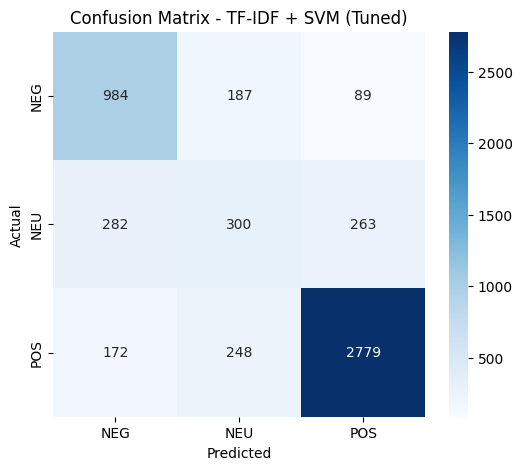


🚀 [2/3] Huấn luyện TF-IDF + Naive Bayes...

📌 KẾT QUẢ: TF-IDF + Naive Bayes
Accuracy : 0.7647
Precision: 0.7344
Recall   : 0.7647
F1-score : 0.7306

📋 Classification Report:
              precision    recall  f1-score   support

         NEG       0.67      0.78      0.72      1260
         NEU       0.51      0.14      0.22       845
         POS       0.82      0.92      0.87      3199

    accuracy                           0.76      5304
   macro avg       0.67      0.62      0.60      5304
weighted avg       0.73      0.76      0.73      5304



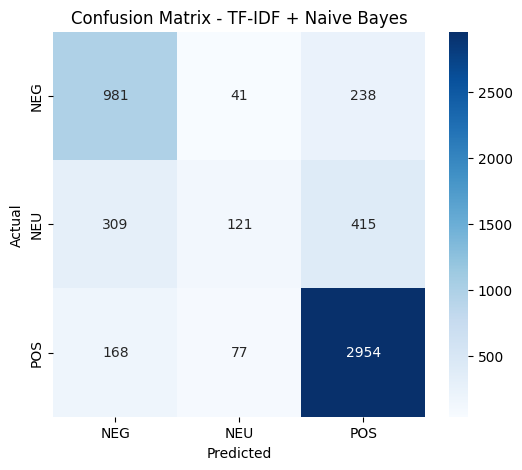


🚀 [3/3] Huấn luyện TF-IDF + Logistic Regression (GridSearchCV)...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
✅ GridSearchCV hoàn thành cho Logistic Regression.
📌 Tham số tốt nhất: {'lr__C': 1, 'lr__max_iter': 1000, 'lr__solver': 'liblinear', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

📌 KẾT QUẢ: TF-IDF + Logistic Regression (Tuned)
Accuracy : 0.7656
Precision: 0.7640
Recall   : 0.7656
F1-score : 0.7641

📋 Classification Report:
              precision    recall  f1-score   support

         NEG       0.69      0.77      0.73      1260
         NEU       0.40      0.36      0.38       845
         POS       0.89      0.87      0.88      3199

    accuracy                           0.77      5304
   macro avg       0.66      0.67      0.66      5304
weighted avg       0.76      0.77      0.76      5304



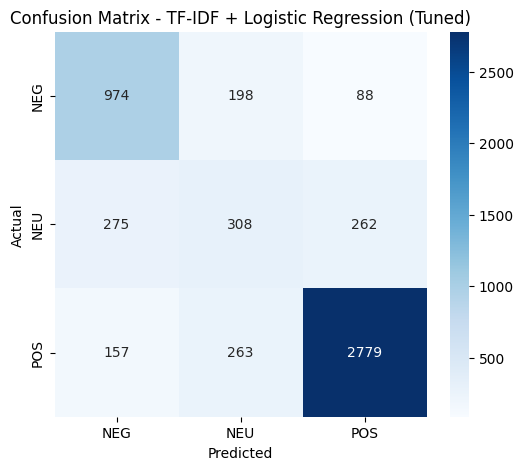


📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH
                                  Model  Accuracy  Precision    Recall  \
2  TF-IDF + Logistic Regression (Tuned)  0.765649   0.764040  0.765649   
0                  TF-IDF + SVM (Tuned)  0.766026   0.762905  0.766026   
1                  TF-IDF + Naive Bayes  0.764706   0.734435  0.764706   

   F1-score  
2  0.764122  
0  0.763352  
1  0.730599  


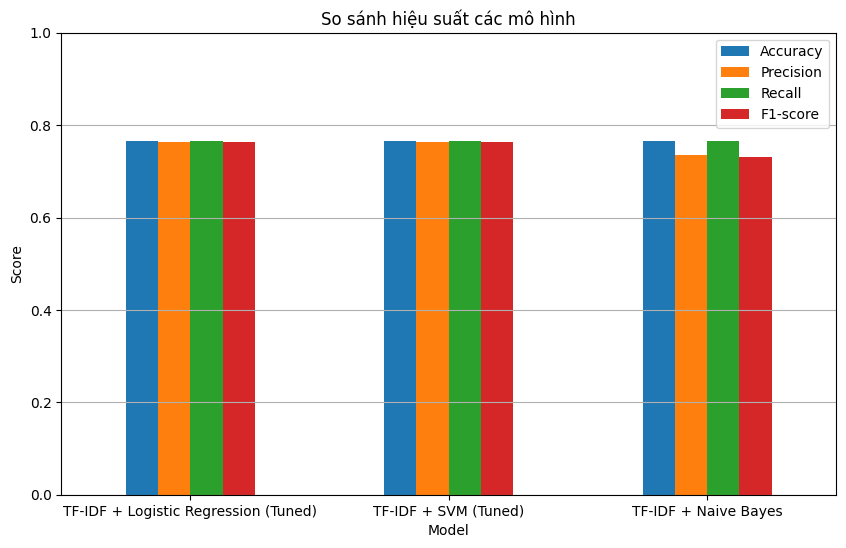


🧪 DEMO DỰ ĐOÁN

📝 Bình luận: sản phẩm rất tốt giao hàng nhanh đóng gói đẹp
👉 Dự đoán cảm xúc: POS

📝 Bình luận: quá tệ thất vọng chất lượng kém
👉 Dự đoán cảm xúc: NEG

📝 Bình luận: shop phục vụ nhiệt tình sẽ ủng hộ tiếp
👉 Dự đoán cảm xúc: POS

📝 Bình luận: Thấy bth
👉 Dự đoán cảm xúc: NEG

📝 Bình luận: hàng xấu không giống hình
👉 Dự đoán cảm xúc: NEG

💾 Đã lưu:
   - model_comparison_results.csv

✅ HOÀN THÀNH HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================================
# 1. ĐỌC DỮ LIỆU
# ============================================================================

DATA_PATH = 'cleaned_data_train_ready.csv'

print("=" * 70)
print("     HUẤN LUYỆN MÔ HÌNH PHÂN TÍCH CẢM XÚC")
print("     TF-IDF + SVM / NB / Logistic Regression")
print("=" * 70)

print("\n📂 Đang đọc dữ liệu...")

df = pd.read_csv(DATA_PATH)

# Fill any NaN values in 'cleaned_comment' with empty strings and ensure string type
df['cleaned_comment'] = df['cleaned_comment'].fillna('').astype(str)

print(f"✅ Tổng dữ liệu: {len(df):,} dòng")
print(df.head())

# ============================================================================
# 2. CHIA TẬP TRAIN / TEST
# ============================================================================

X = df['cleaned_comment']
y = df['label']

print("\n📊 Phân phối nhãn:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Train size: {len(X_train):,}")
print(f"✅ Test size : {len(X_test):,}")

# ============================================================================
# 3. TF-IDF VECTORIZATION (for Naive Bayes baseline)
# ============================================================================

print("\n⚙️ Đang vector hóa TF-IDF (cho Naive Bayes baseline)...")

# Keep a base TF-IDF for Naive Bayes, other models will use pipelines
base_tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf_base = base_tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf_base = base_tfidf_vectorizer.transform(X_test)

print("✅ Vector hóa cơ bản thành công")
print(f"📌 Số chiều vector cơ bản: {X_train_tfidf_base.shape[1]:,}")

# ============================================================================
# HÀM ĐÁNH GIÁ MÔ HÌNH
# ============================================================================

def evaluate_model(model_name, y_test, y_pred):

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("\n" + "="*70)
    print(f"📌 KẾT QUẢ: {model_name}")
    print("="*70)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': pre,
        'Recall': rec,
        'F1-score': f1
    }

# ============================================================================
# 4. TF-IDF + SVM (with GridSearchCV)
# ============================================================================

print("\n🚀 [1/3] Huấn luyện TF-IDF + SVM (GridSearchCV)...")

# Create a pipeline for TF-IDF and LinearSVC
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', LinearSVC(random_state=42, class_weight='balanced', dual='auto'))
])

# Define the parameter grid for GridSearchCV for SVM
param_grid_svm = [
    { # Word-level TF-IDF
        'tfidf__analyzer': ['word'],
        'tfidf__max_features': [20000], # Reduced options for speed
        'tfidf__ngram_range': [(1, 2)], # Reduced options for speed
        'svm__C': [0.1, 1, 10], # Reduced options for speed
        'svm__loss': ['squared_hinge'], # Fixed for speed
        'svm__max_iter': [1000] # Fixed for speed
    },
    { # Character-level TF-IDF
        'tfidf__analyzer': ['char_wb'],
        'tfidf__max_features': [20000], # Reduced options for speed
        'tfidf__ngram_range': [(2, 4)], # Reduced options for speed
        'svm__C': [0.1, 1, 10], # Reduced options for speed
        'svm__loss': ['squared_hinge'], # Fixed for speed
        'svm__max_iter': [1000] # Fixed for speed
    }
]

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    cv=3, # 3-fold cross-validation
    verbose=1,
    n_jobs=-1, # Use all available cores
    scoring='f1_weighted' # Optimize for F1-score
)

# Fit GridSearchCV (this will train multiple models)
grid_search_svm.fit(X_train, y_train)

# Get the best model
best_svm_model = grid_search_svm.best_estimator_

print("✅ GridSearchCV hoàn thành cho LinearSVC.")
print(f"📌 Tham số tốt nhất cho SVM: {grid_search_svm.best_params_}")

y_pred_svm = best_svm_model.predict(X_test)

svm_result = evaluate_model(
    "TF-IDF + SVM (Tuned)",
    y_test,
    y_pred_svm
)

# ============================================================================
# 5. TF-IDF + NAIVE BAYES
# ============================================================================

print("\n🚀 [2/3] Huấn luyện TF-IDF + Naive Bayes...")

nb_model = MultinomialNB()

# Use the globally transformed TF-IDF for Naive Bayes
nb_model.fit(X_train_tfidf_base, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf_base)

nb_result = evaluate_model(
    "TF-IDF + Naive Bayes",
    y_test,
    y_pred_nb
)

# ============================================================================
# 6. TF-IDF + LOGISTIC REGRESSION (with GridSearchCV)
# ============================================================================

print("\n🚀 [3/3] Huấn luyện TF-IDF + Logistic Regression (GridSearchCV)....")

# Create a pipeline for TF-IDF and Logistic Regression
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced')) # Added class_weight
])

# Define the parameter grid for GridSearchCV
param_grid_lr = {
    'tfidf__max_features': [20000],
    'tfidf__ngram_range': [(1, 2)],
    'lr__C': [1, 10],
    'lr__solver': ['liblinear'], # Optimized solver for efficiency
    'lr__max_iter': [1000]
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=3, # 3-fold cross-validation
    verbose=1,
    n_jobs=-1, # Use all available cores
    scoring='f1_weighted' # Optimize for F1-score
)

# Fit GridSearchCV (this will train multiple models)
grid_search_lr.fit(X_train, y_train)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

print("✅ GridSearchCV hoàn thành cho Logistic Regression.")
print(f"📌 Tham số tốt nhất: {grid_search_lr.best_params_}")

y_pred_lr = best_lr_model.predict(X_test)

lr_result = evaluate_model(
    "TF-IDF + Logistic Regression (Tuned)",
    y_test,
    y_pred_lr
)

# ============================================================================
# 7. SO SÁNH KẾT QUẢ
# ============================================================================

print("\n" + "="*70)
print("📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH")
print("="*70)

results_df = pd.DataFrame([
    svm_result,
    nb_result,
    lr_result
])

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

print(results_df)

# ============================================================================
# 8. VẼ BIỂU ĐỒ SO SÁNH
# ============================================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

results_df.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('So sánh hiệu suất các mô hình')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid(axis='y')

plt.show()

# ============================================================================
# 9. DỰ ĐOÁN THỬ NGHIỆM
# ============================================================================

print("\n" + "="*70)
print("🧪 DEMO DỰ ĐOÁN")
print("="*70)

samples = [
    "sản phẩm rất tốt giao hàng nhanh đóng gói đẹp",
    "quá tệ thất vọng chất lượng kém",
    "shop phục vụ nhiệt tình sẽ ủng hộ tiếp",
        "Thấy bth",
    "hàng xấu không giống hình"
]

for text in samples:

    # Use the best_svm_model from GridSearchCV for prediction as requested
    pred = best_svm_model.predict([text])[0]

    print(f"\n📝 Bình luận: {text}")
    print(f"👉 Dự đoán cảm xúc: {pred}")

# ============================================================================
# 10. LƯU KẾT QUẢ
# ============================================================================

results_df.to_csv(
    'model_comparison_results.csv',
    index=False,
    encoding='utf-8-sig'
)

print("\n💾 Đã lưu:")
print("   - model_comparison_results.csv")

print("\n✅ HOÀN THÀNH HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH")